# Backtest Results Viewer

Visualize the output from `python run_backtest.py`. Re-run the backtest first if you want fresh results, then run this notebook from top to bottom.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)

# Locate project root by searching upward for config.yaml and src/.
p = Path.cwd().resolve()
ROOT = p if (p / 'config.yaml').exists() and (p / 'src').exists() else next(
    (parent for parent in p.parents if (parent / 'config.yaml').exists() and (parent / 'src').exists()),
    p,
)
sys.path.insert(0, str(ROOT))

RESULTS_DIR = ROOT / 'data' / 'results'
print('Project root:', ROOT)
print('Results dir: ', RESULTS_DIR)

Project root: C:\Users\bjorn\OneDrive\Dokument\trading\calendar_scanner
Results dir:  C:\Users\bjorn\OneDrive\Dokument\trading\calendar_scanner\data\results


## Load Results

In [2]:
trade_log_path = RESULTS_DIR / 'trade_log.csv'
metrics_path = RESULTS_DIR / 'metrics.json'
regimes_path = RESULTS_DIR / 'regimes.json'
features_path = RESULTS_DIR / 'features.parquet'

missing = [p.name for p in [trade_log_path, metrics_path, regimes_path] if not p.exists()]
if missing:
    raise FileNotFoundError(f'Missing backtest output files in {RESULTS_DIR}: {missing}. Run python run_backtest.py first.')

trades = pd.read_csv(trade_log_path)
for col in ['entry_date', 'exit_date']:
    if col in trades.columns:
        trades[col] = pd.to_datetime(trades[col], errors='coerce')

with metrics_path.open('r', encoding='utf-8') as f:
    metrics = json.load(f)
with regimes_path.open('r', encoding='utf-8') as f:
    regimes = json.load(f)

features = pd.read_parquet(features_path) if features_path.exists() else pd.DataFrame()
if not features.empty and 'tradeDate' in features.columns:
    features['tradeDate'] = pd.to_datetime(features['tradeDate'], errors='coerce')

print(f'Trades:   {len(trades):,}')
print(f'Features: {len(features):,}')
display(trades.head())

Trades:   556
Features: 69,455


,ticker,entry_date,exit_date,entry_value,entry_cost,gross_exit_value,exit_value,gross_pnl,pnl,pnl_pct,transaction_costs,capital_deployed,gross_capital_deployed,return_on_capital_pct,gross_return_on_capital_pct,contracts,hold_days,exit_reason,entry_zscore,entry_pctile,entry_front_iv,entry_back_iv,entry_iv_spread,exit_front_iv,exit_back_iv,exit_iv_spread,iv_spread_compression
0,INTC,2016-03-30,2016-04-07,0.644566,0.676903,0.747829,0.712394,144.567252,49.686650,0.160204,94.880602,947.664875,902.393082,5.243061,16.020430,14,8,profit_target,0.810769,79.661017,24.8027,22.7724,2.0303,28.9016,24.0110,4.8906,2.408807
1,NFLX,2016-03-30,2016-04-12,4.984537,5.147073,4.986891,4.824284,0.235416,-32.278866,0.000472,32.514281,514.707260,498.453650,-6.271306,0.047229,1,13,time_stop,0.971186,84.745763,65.1011,53.5884,11.5127,59.6867,48.9202,10.7665,0.935185
2,GLD,2016-04-19,2016-04-29,1.067291,1.112310,1.341386,1.288144,219.275519,140.667262,0.256813,78.608256,889.848175,853.833180,15.808007,25.681307,8,10,profit_target,0.832310,82.191781,16.4601,15.6607,0.7994,18.7521,19.2673,-0.5152,-0.644483
3,XLF,2016-05-05,2016-05-09,0.270070,0.291172,0.311205,0.288868,139.858151,-7.831845,0.152312,147.689996,989.984651,918.237525,-0.791108,15.231152,34,4,profit_target,1.410776,90.588235,20.4696,18.7695,1.7001,17.6497,18.6148,-0.9651,-0.567672
4,XLF,2016-05-27,2016-06-08,0.238632,0.258791,0.279386,0.258004,154.865141,-2.988828,0.170782,157.853969,983.404250,906.800242,-0.303927,17.078198,38,12,profit_target,1.077736,84.158416,16.0079,14.8075,1.2004,15.2257,16.4707,-1.2450,-1.037154


## Summary Metrics

In [3]:
summary_keys = [
    'total_trades', 'win_rate_pct', 'avg_pnl_usd', 'median_pnl_usd', 'total_pnl_usd',
    'profit_factor', 'expectancy_usd', 'avg_pnl_pct', 'avg_hold_days', 'max_drawdown_pct',
    'sharpe_ratio', 'sortino_ratio', 'calmar_ratio', 'annualized_return',
]
summary = pd.DataFrame(
    [{'metric': key, 'value': metrics.get(key)} for key in summary_keys if key in metrics]
)
display(summary)

exit_reasons = metrics.get('exit_reasons', {})
if exit_reasons:
    display(pd.Series(exit_reasons, name='count').sort_values(ascending=False).to_frame())

,metric,value
0,total_trades,556.00
1,win_rate_pct,96.20
2,avg_pnl_usd,100.87
3,median_pnl_usd,99.07
4,total_pnl_usd,56085.07
5,profit_factor,19.81
6,expectancy_usd,100.87
7,avg_pnl_pct,18.52
8,avg_hold_days,9.90
9,max_drawdown_pct,-1.15


,count
profit_target,520
time_stop,31
stop_loss,5


## Saved Backtest Plots

### equity_curve.png

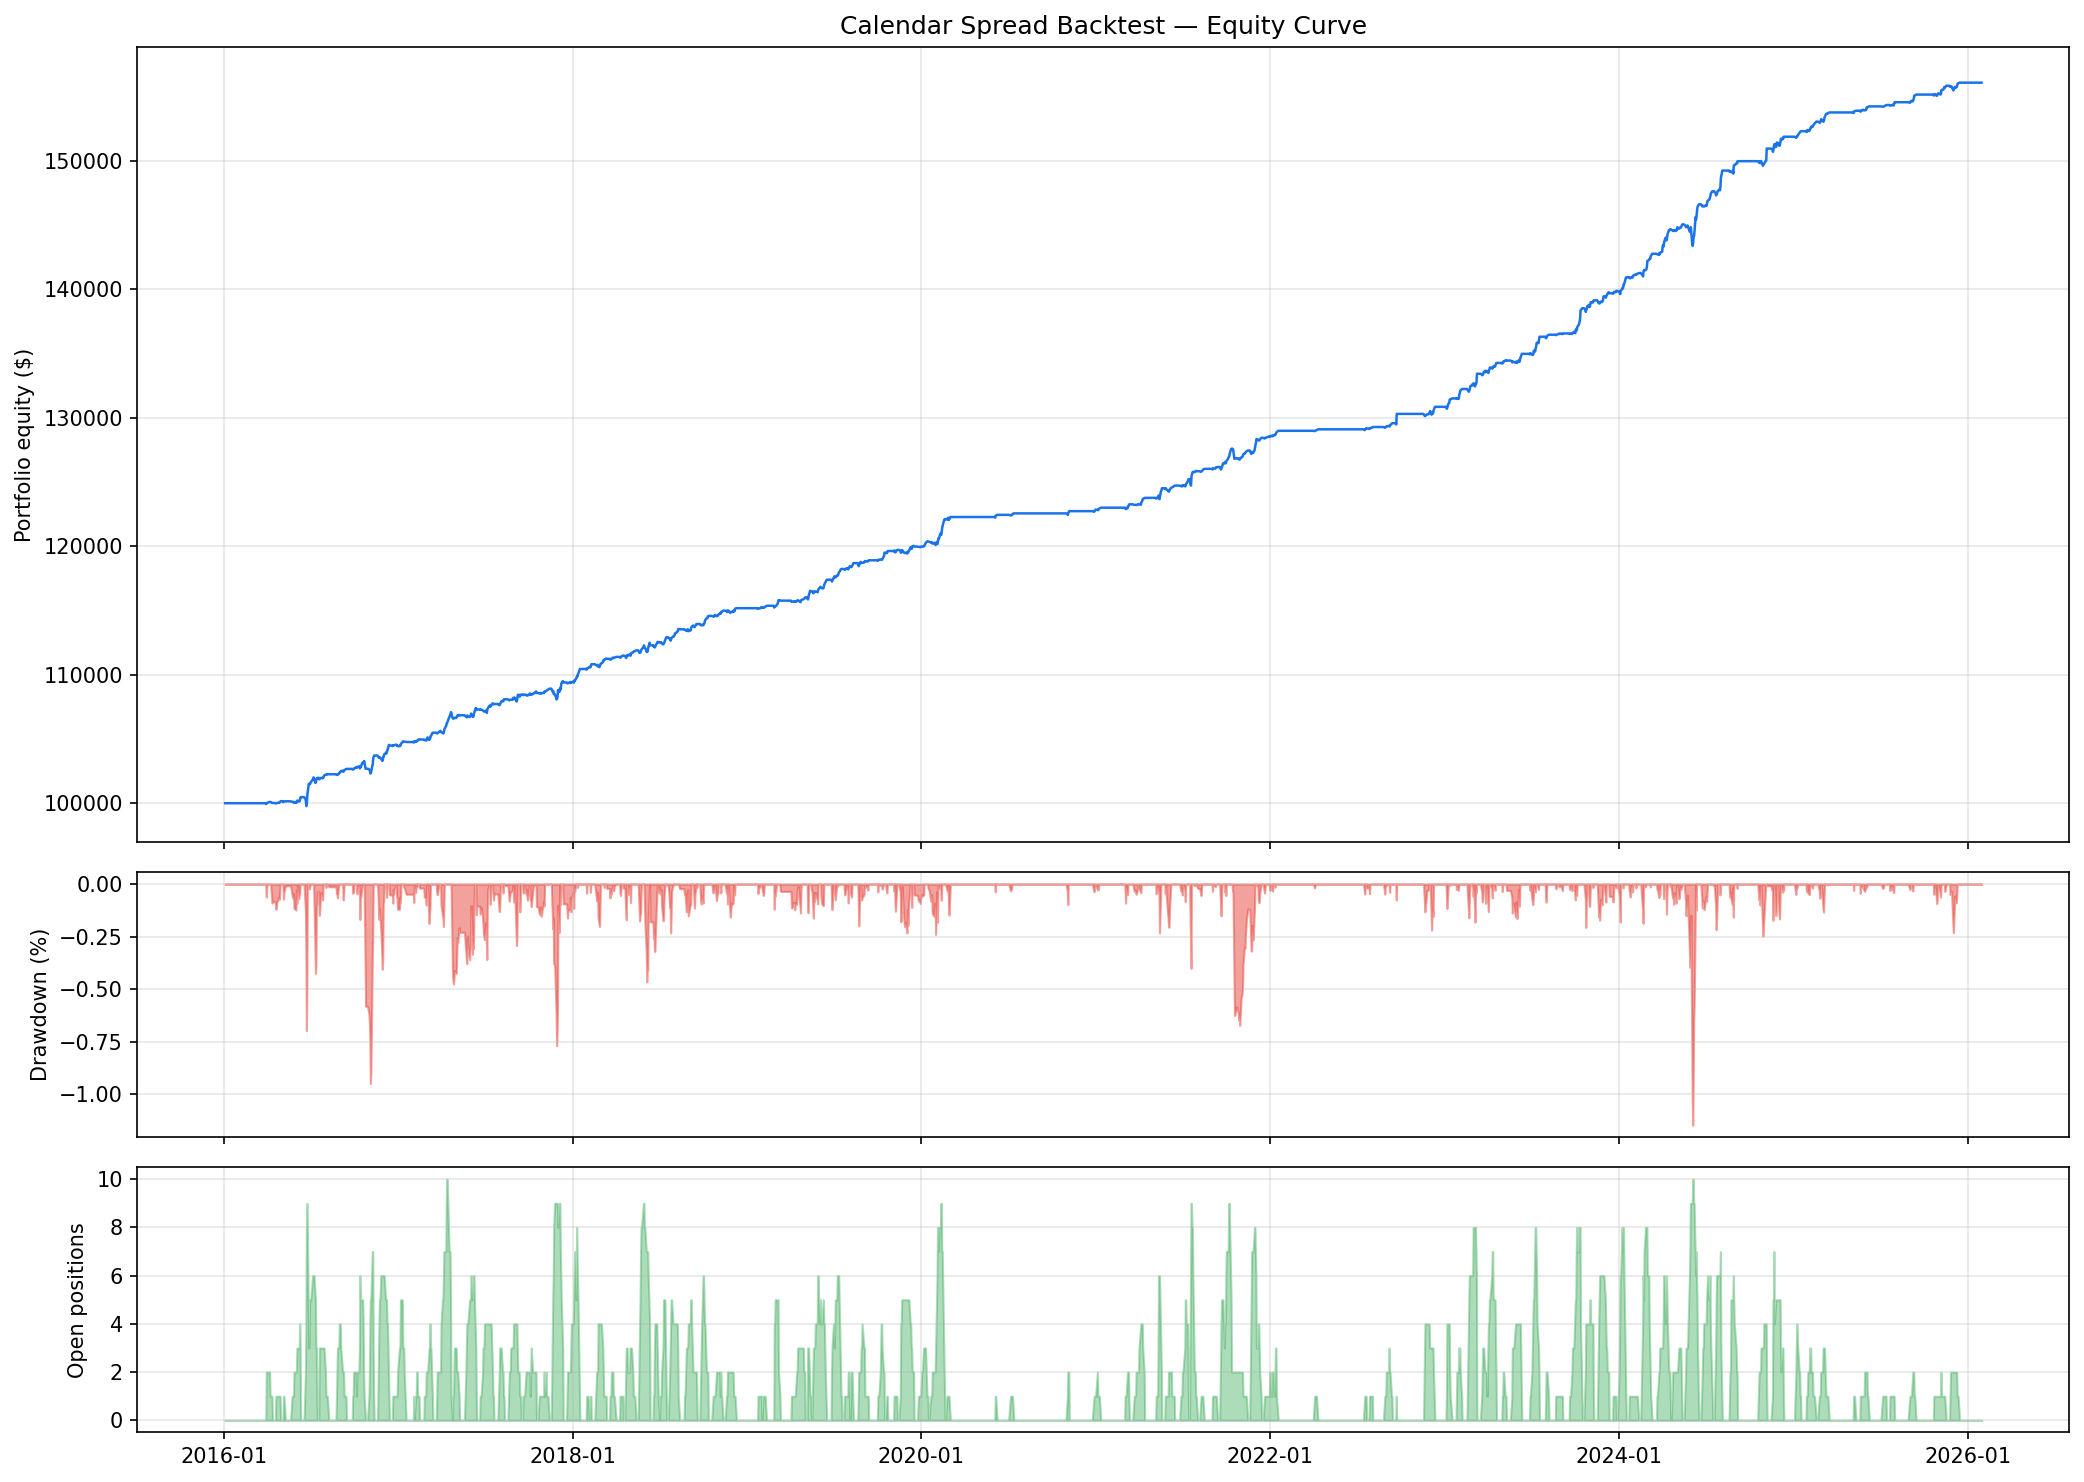

### pnl_distribution.png

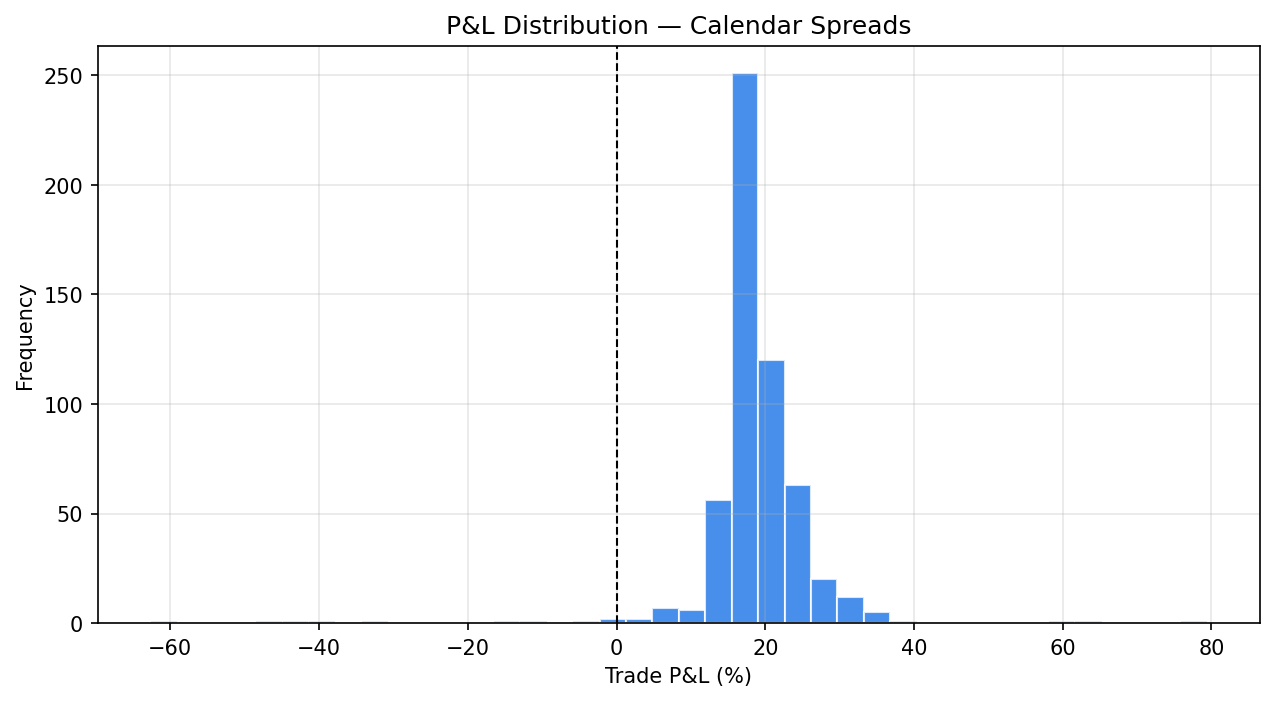

### monthly_heatmap.png

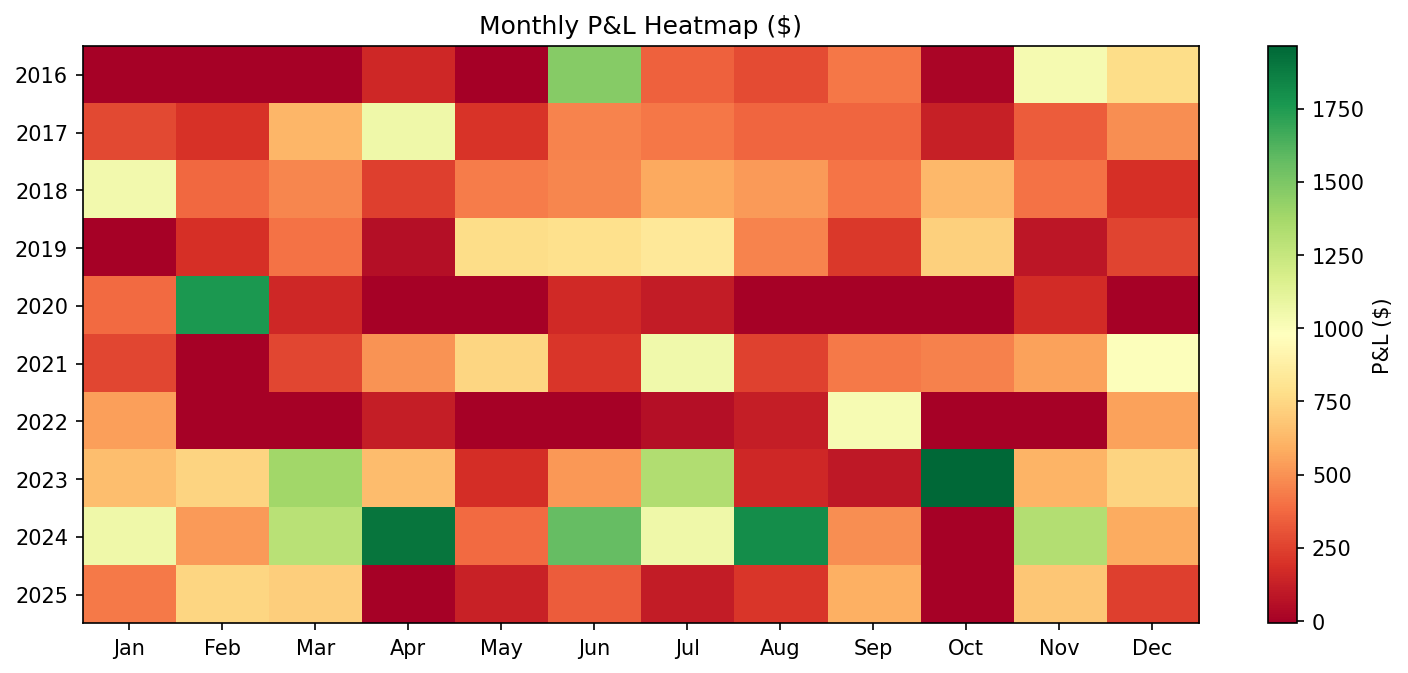

### greek_analysis.png

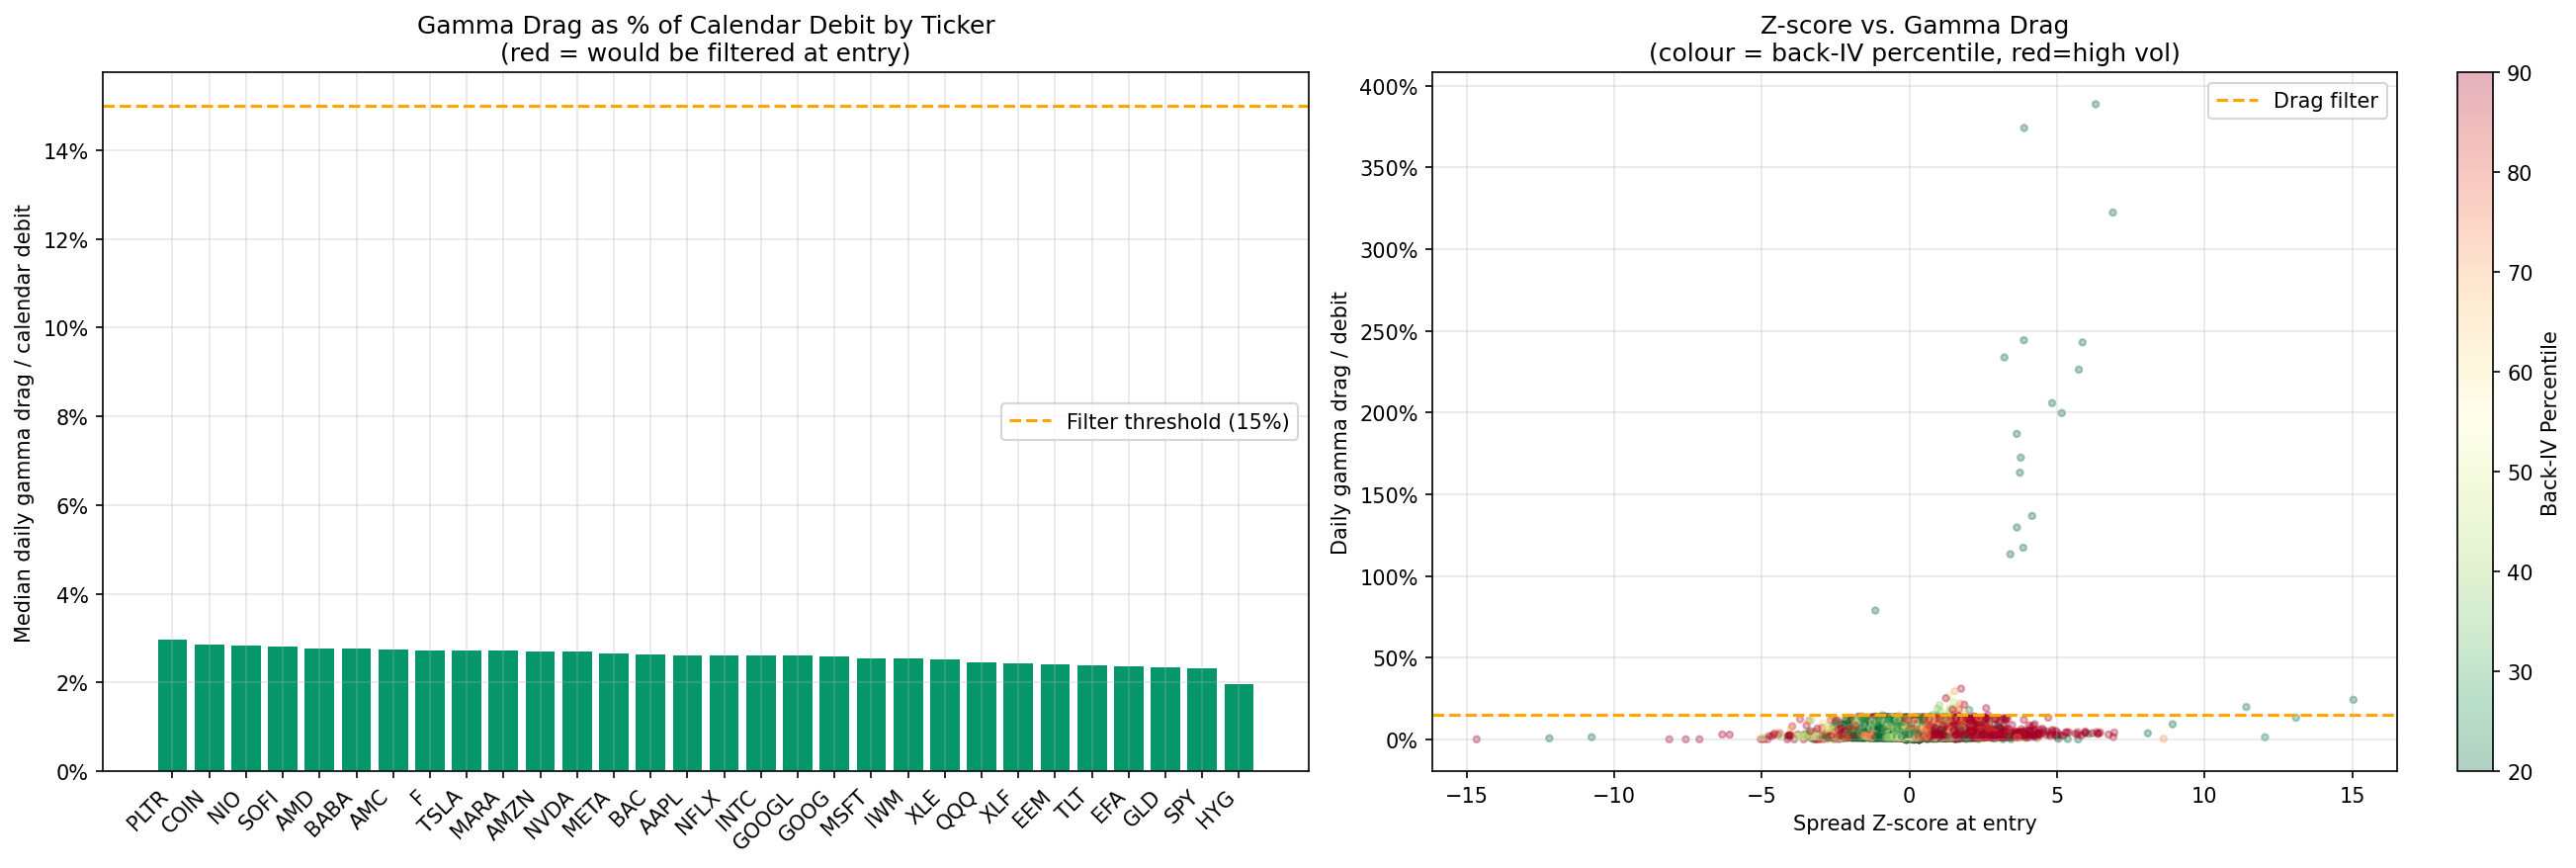

### term_structure_distribution.png

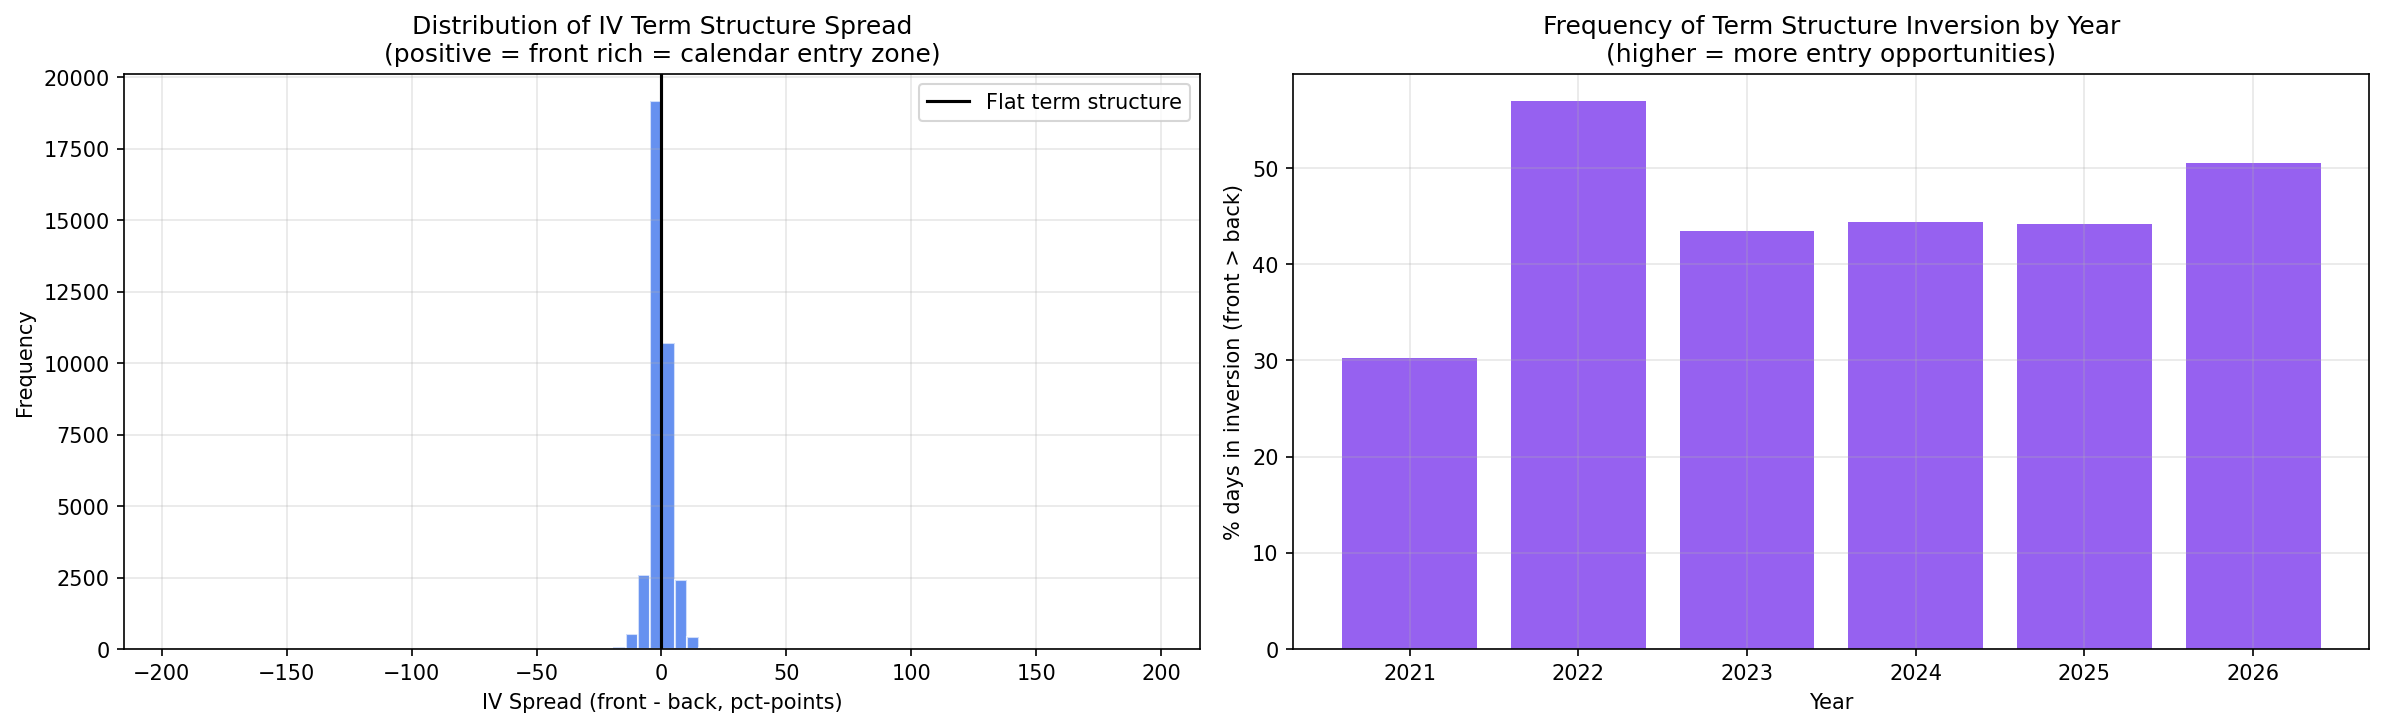

In [4]:
plot_files = [
    'equity_curve.png',
    'pnl_distribution.png',
    'monthly_heatmap.png',
    'greek_analysis.png',
    'term_structure_distribution.png',
]

for name in plot_files:
    path = RESULTS_DIR / name
    if path.exists():
        display(Markdown(f'### {name}'))
        display(Image(filename=str(path)))

## Trade Filters

Edit these values and re-run the following cells to focus the charts.

In [5]:
TICKERS = None       # Example: ['SPY', 'QQQ']; None = all
START_DATE = None    # Example: '2021-01-01'; None = no lower bound
END_DATE = None      # Example: '2026-01-31'; None = no upper bound

filtered = trades.copy()
if TICKERS:
    filtered = filtered[filtered['ticker'].isin(TICKERS)]
if START_DATE:
    filtered = filtered[filtered['entry_date'] >= pd.Timestamp(START_DATE)]
if END_DATE:
    filtered = filtered[filtered['entry_date'] <= pd.Timestamp(END_DATE)]

filtered = filtered.sort_values(['exit_date', 'entry_date']).reset_index(drop=True)
print(f'Filtered trades: {len(filtered):,} of {len(trades):,}')
display(filtered.head(10))

Filtered trades: 556 of 556


,ticker,entry_date,exit_date,entry_value,entry_cost,gross_exit_value,exit_value,gross_pnl,pnl,pnl_pct,transaction_costs,capital_deployed,gross_capital_deployed,return_on_capital_pct,gross_return_on_capital_pct,contracts,hold_days,exit_reason,entry_zscore,entry_pctile,entry_front_iv,entry_back_iv,entry_iv_spread,exit_front_iv,exit_back_iv,exit_iv_spread,iv_spread_compression
0,INTC,2016-03-30,2016-04-07,0.644566,0.676903,0.747829,0.712394,144.567252,49.686650,0.160204,94.880602,947.664875,902.393082,5.243061,16.020430,14,8,profit_target,0.810769,79.661017,24.8027,22.7724,2.0303,28.9016,24.0110,4.8906,2.408807
1,NFLX,2016-03-30,2016-04-12,4.984537,5.147073,4.986891,4.824284,0.235416,-32.278866,0.000472,32.514281,514.707260,498.453650,-6.271306,0.047229,1,13,time_stop,0.971186,84.745763,65.1011,53.5884,11.5127,59.6867,48.9202,10.7665,0.935185
2,GLD,2016-04-19,2016-04-29,1.067291,1.112310,1.341386,1.288144,219.275519,140.667262,0.256813,78.608256,889.848175,853.833180,15.808007,25.681307,8,10,profit_target,0.832310,82.191781,16.4601,15.6607,0.7994,18.7521,19.2673,-0.5152,-0.644483
3,XLF,2016-05-05,2016-05-09,0.270070,0.291172,0.311205,0.288868,139.858151,-7.831845,0.152312,147.689996,989.984651,918.237525,-0.791108,15.231152,34,4,profit_target,1.410776,90.588235,20.4696,18.7695,1.7001,17.6497,18.6148,-0.9651,-0.567672
4,XLF,2016-05-27,2016-06-08,0.238632,0.258791,0.279386,0.258004,154.865141,-2.988828,0.170782,157.853969,983.404250,906.800242,-0.303927,17.078198,38,12,profit_target,1.077736,84.158416,16.0079,14.8075,1.2004,15.2257,16.4707,-1.2450,-1.037154
5,TLT,2016-06-02,2016-06-09,1.110549,1.156866,1.302470,1.250396,153.536957,74.824492,0.172816,78.712465,925.492451,888.439273,8.084830,17.281649,8,7,profit_target,0.930470,84.615385,12.2879,12.2343,0.0536,12.7298,12.7389,-0.0091,-0.169776
6,EFA,2016-05-23,2016-06-10,0.638322,0.670471,0.783598,0.747090,203.386638,107.266024,0.227591,96.120614,938.659753,893.650245,11.427573,22.759087,14,18,profit_target,0.971543,84.536082,18.1476,17.6406,0.5070,22.3563,18.0743,4.2820,8.445759
7,GLD,2016-06-08,2016-06-10,1.513893,1.572310,1.756733,1.691031,145.703596,71.232323,0.160407,74.471273,943.386173,908.336090,7.550707,16.040714,6,2,profit_target,0.904983,80.555556,17.9180,17.3005,0.6175,19.7899,19.5672,0.2227,0.360648
8,SPY,2016-06-08,2016-06-10,1.993165,2.065960,2.333464,2.250460,136.119576,73.800030,0.170733,62.319546,826.383952,797.265973,8.930477,17.073296,4,2,profit_target,0.854488,79.629630,12.1955,12.2155,-0.0200,13.9756,14.1229,-0.1473,7.365000
9,EFA,2016-06-23,2016-06-24,0.515450,0.543914,0.615097,0.583644,169.399585,67.541681,0.193320,101.857904,924.653233,876.265275,7.304542,19.331998,17,1,profit_target,1.767095,94.117647,20.7656,17.4655,3.3001,27.4565,23.8579,3.5986,1.090452


## P&L and Trade Diagnostics

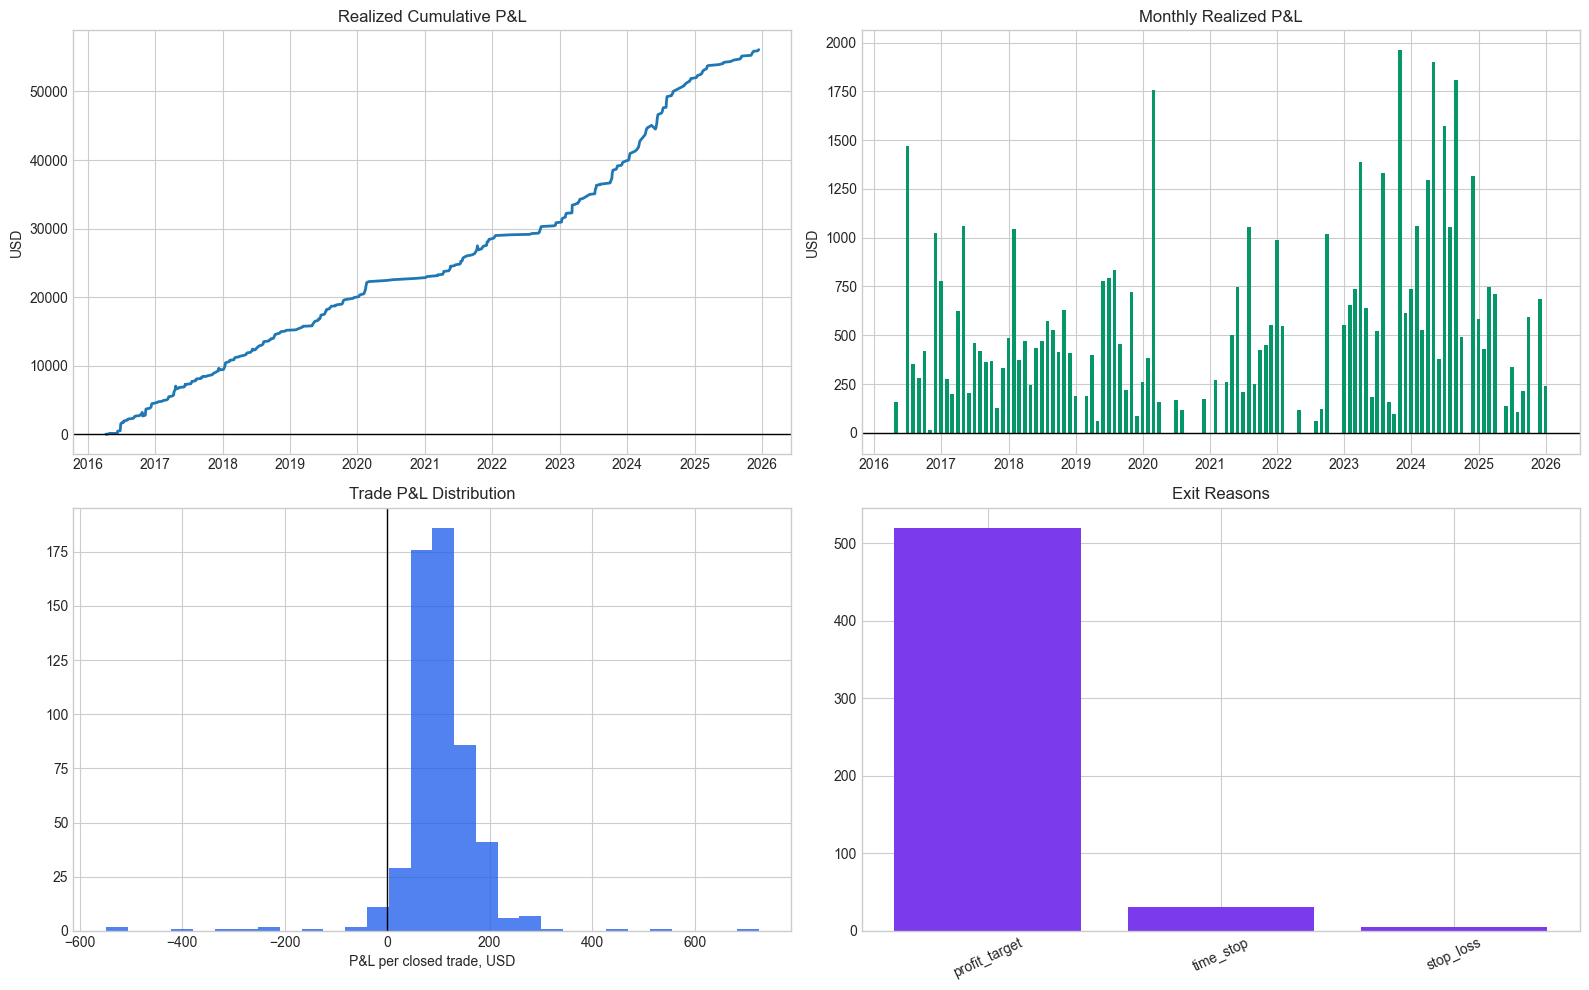

In [6]:
if filtered.empty:
    raise ValueError('No trades match the current filters.')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Realized cumulative P&L by exit date. This is realized P&L, not daily MTM equity.
realized = filtered.dropna(subset=['exit_date']).groupby('exit_date')['pnl'].sum().sort_index().cumsum()
axes[0, 0].plot(realized.index, realized.values, linewidth=2)
axes[0, 0].axhline(0, color='black', linewidth=1)
axes[0, 0].set_title('Realized Cumulative P&L')
axes[0, 0].set_ylabel('USD')

# Monthly realized P&L.
monthly = filtered.dropna(subset=['exit_date']).set_index('exit_date')['pnl'].resample('ME').sum()
colors = np.where(monthly.values >= 0, '#059669', '#dc2626')
axes[0, 1].bar(monthly.index, monthly.values, width=20, color=colors)
axes[0, 1].axhline(0, color='black', linewidth=1)
axes[0, 1].set_title('Monthly Realized P&L')
axes[0, 1].set_ylabel('USD')

# P&L distribution.
axes[1, 0].hist(filtered['pnl'].dropna(), bins=30, color='#2563eb', alpha=0.8)
axes[1, 0].axvline(0, color='black', linewidth=1)
axes[1, 0].set_title('Trade P&L Distribution')
axes[1, 0].set_xlabel('P&L per closed trade, USD')

# Exit reason mix.
exit_counts = filtered['exit_reason'].fillna('unknown').value_counts()
axes[1, 1].bar(exit_counts.index, exit_counts.values, color='#7c3aed')
axes[1, 1].set_title('Exit Reasons')
axes[1, 1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

## Trades Per Year


,trades,total_pnl,avg_pnl,win_rate,avg_hold_days
year,,,,,
2016,60,4652.83,77.55,91.67,9.48
2017,76,5027.75,66.15,89.47,11.33
2018,67,5499.23,82.08,97.01,10.42
2019,54,4895.91,90.67,98.15,10.91
2020,25,2787.95,111.52,100.00,8.08
2021,63,5792.76,91.95,95.24,9.33
2022,14,2197.60,156.97,100.00,9.64
2023,78,9025.00,115.71,100.00,9.83
2024,89,11999.40,134.82,97.75,10.08


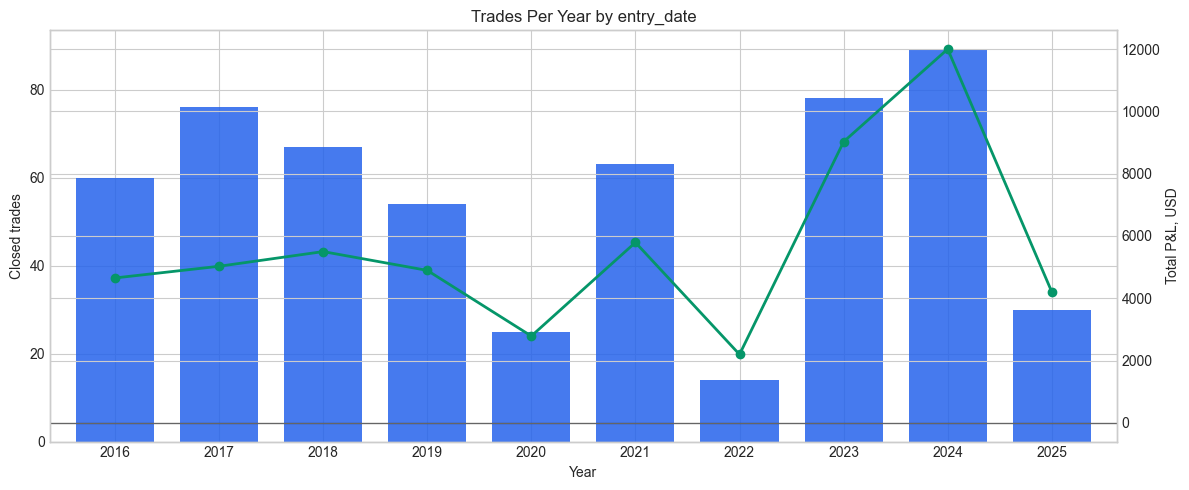

In [7]:
year_source = filtered.copy()
date_col = 'entry_date' if 'entry_date' in year_source.columns else 'exit_date'
year_source[date_col] = pd.to_datetime(year_source[date_col], errors='coerce')
year_source = year_source.dropna(subset=[date_col])
year_source['year'] = year_source[date_col].dt.year

trades_per_year = (
    year_source.groupby('year')
    .agg(
        trades=('pnl', 'size'),
        total_pnl=('pnl', 'sum'),
        avg_pnl=('pnl', 'mean'),
        win_rate=('pnl', lambda s: (s > 0).mean() * 100),
        avg_hold_days=('hold_days', 'mean'),
    )
    .round(2)
)
display(trades_per_year)

fig, ax1 = plt.subplots(figsize=(12, 5))
trades_per_year['trades'].plot(kind='bar', ax=ax1, color='#2563eb', alpha=0.85, width=0.75)
ax1.set_title(f'Trades Per Year by {date_col}')
ax1.set_xlabel('Year')
ax1.set_ylabel('Closed trades')
ax1.tick_params(axis='x', rotation=0)

ax2 = ax1.twinx()
ax2.plot(range(len(trades_per_year.index)), trades_per_year['total_pnl'], color='#059669', marker='o', linewidth=2)
ax2.axhline(0, color='black', linewidth=1, alpha=0.5)
ax2.set_ylabel('Total P&L, USD')

plt.tight_layout()
plt.show()


## Ticker Breakdown

,trades,total_pnl,avg_pnl,win_rate,avg_hold_days,avg_entry_zscore,avg_entry_pctile
ticker,,,,,,,
GLD,60,7111.105288,118.518421,100.000000,10.683333,1.178189,88.195909
TLT,64,6624.492078,103.507689,100.000000,9.281250,1.191182,87.009314
EEM,38,4765.770093,125.415002,100.000000,12.131579,1.210252,90.335858
IWM,41,4286.486309,104.548447,100.000000,9.902439,1.115660,88.313182
SPY,37,3465.808934,93.670512,89.189189,13.324324,1.200791,87.502111
MU,27,3330.867705,123.365471,100.000000,7.629630,1.172868,84.167036
QQQ,27,3316.610548,122.837428,100.000000,9.555556,1.021742,85.919258
XLE,31,3249.277786,104.815412,100.000000,11.387097,1.327271,87.676083
EFA,31,2406.790916,77.638417,90.322581,12.580645,1.326442,89.830653


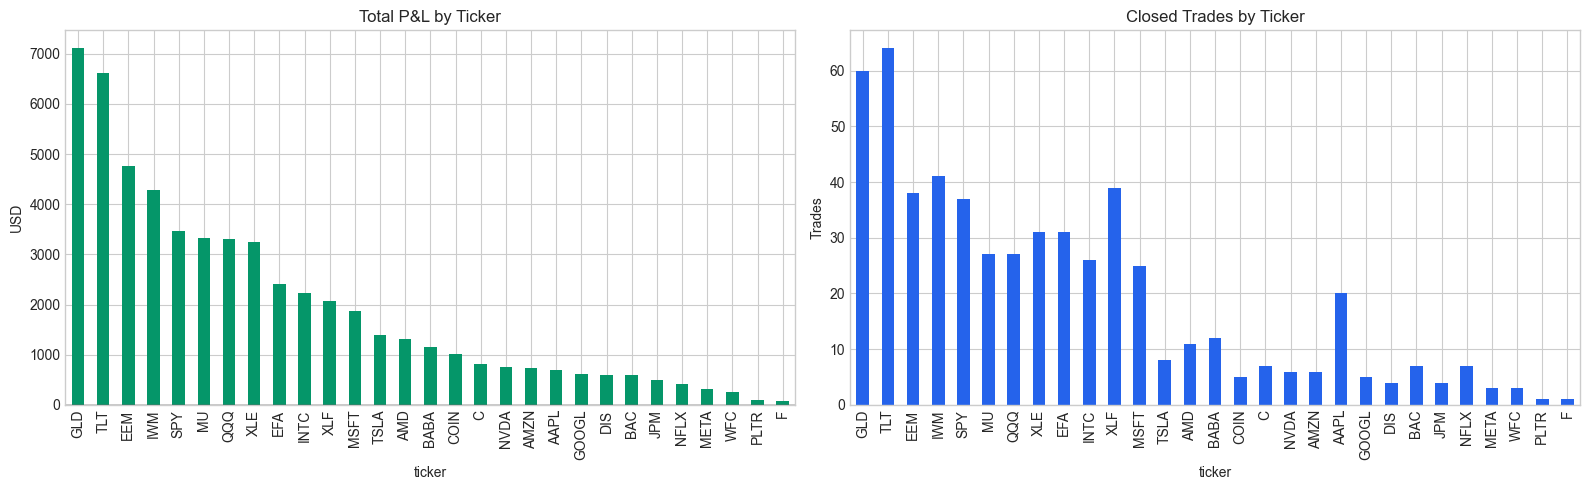

In [8]:
ticker_summary = (
    filtered.groupby('ticker')
    .agg(
        trades=('pnl', 'size'),
        total_pnl=('pnl', 'sum'),
        avg_pnl=('pnl', 'mean'),
        win_rate=('pnl', lambda s: (s > 0).mean() * 100),
        avg_hold_days=('hold_days', 'mean'),
        avg_entry_zscore=('entry_zscore', 'mean'),
        avg_entry_pctile=('entry_pctile', 'mean'),
    )
    .sort_values('total_pnl', ascending=False)
)
display(ticker_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ticker_summary['total_pnl'].plot(kind='bar', ax=axes[0], color=np.where(ticker_summary['total_pnl'] >= 0, '#059669', '#dc2626'))
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Total P&L by Ticker')
axes[0].set_ylabel('USD')

ticker_summary['trades'].plot(kind='bar', ax=axes[1], color='#2563eb')
axes[1].set_title('Closed Trades by Ticker')
axes[1].set_ylabel('Trades')
plt.tight_layout()
plt.show()

## Entry Signal Quality

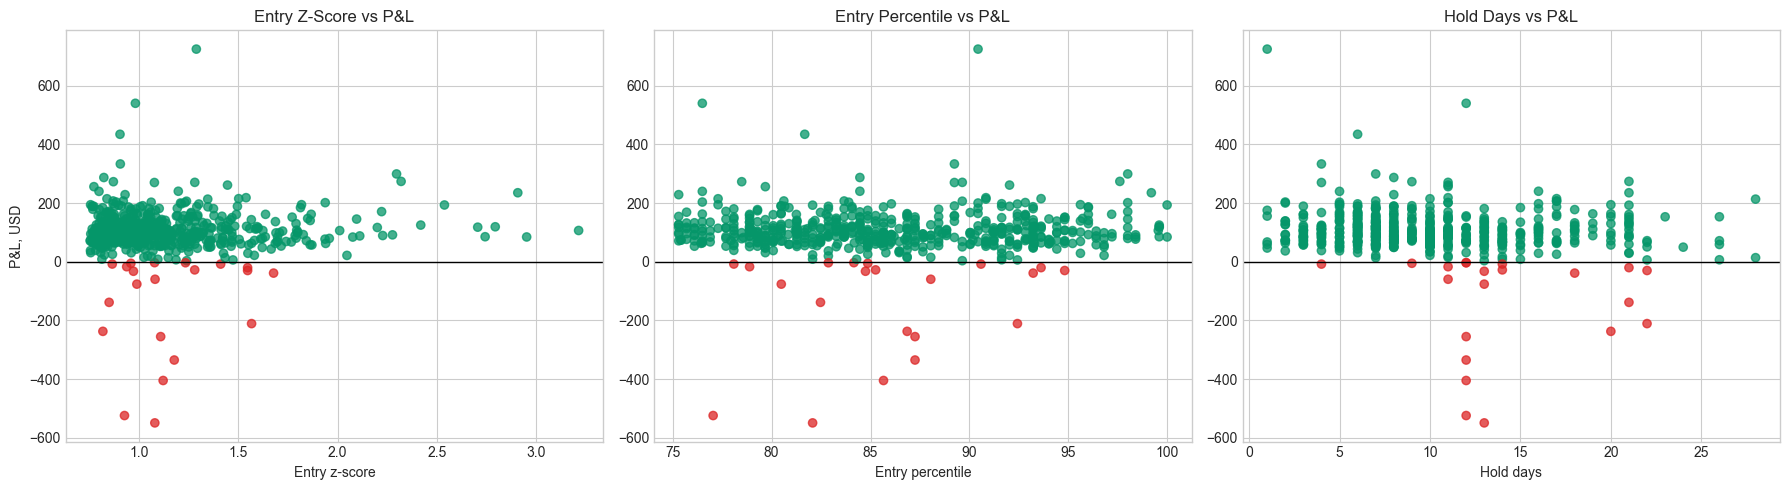

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

scatter_df = filtered.copy()
win_colors = np.where(scatter_df['pnl'] >= 0, '#059669', '#dc2626')

axes[0].scatter(scatter_df['entry_zscore'], scatter_df['pnl'], c=win_colors, alpha=0.75)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Entry Z-Score vs P&L')
axes[0].set_xlabel('Entry z-score')
axes[0].set_ylabel('P&L, USD')

axes[1].scatter(scatter_df['entry_pctile'], scatter_df['pnl'], c=win_colors, alpha=0.75)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Entry Percentile vs P&L')
axes[1].set_xlabel('Entry percentile')

axes[2].scatter(scatter_df['hold_days'], scatter_df['pnl'], c=win_colors, alpha=0.75)
axes[2].axhline(0, color='black', linewidth=1)
axes[2].set_title('Hold Days vs P&L')
axes[2].set_xlabel('Hold days')

plt.tight_layout()
plt.show()

## Regime and Feature Context

In [10]:
by_ticker = regimes.get('by_ticker', {}) if isinstance(regimes, dict) else {}
if by_ticker:
    regime_df = pd.DataFrame(by_ticker).T
    display(regime_df.sort_values('total_pnl_usd' if 'total_pnl_usd' in regime_df.columns else regime_df.columns[0], ascending=False))
else:
    print('No by_ticker regime data found in regimes.json')

if not features.empty:
    feature_counts = features.groupby('ticker').size().sort_values(ascending=False).rename('feature_rows').to_frame()
    display(feature_counts)
    if {'tradeDate', 'ticker'}.issubset(features.columns):
        yearly = features.assign(year=features['tradeDate'].dt.year).groupby(['year', 'ticker']).size().unstack(fill_value=0)
        display(yearly.tail(10))

,trades,win_rate,avg_pnl_pct,total_pnl
TLT,64.0,100.0,18.73,6624.49
GLD,60.0,100.0,20.13,7111.11
IWM,41.0,100.0,18.19,4286.49
XLF,39.0,89.7,18.87,2072.05
EEM,38.0,100.0,23.05,4765.77
SPY,37.0,89.2,16.35,3465.81
EFA,31.0,90.3,16.76,2406.79
XLE,31.0,100.0,18.75,3249.28
MU,27.0,100.0,19.53,3330.87
QQQ,27.0,100.0,19.52,3316.61


,feature_rows
ticker,
AAPL,2534
AMD,2534
AMZN,2534
BABA,2534
BAC,2534
C,2534
DIS,2534
EEM,2534
EFA,2534


ticker,AAPL,AMD,AMZN,BABA,BAC,C,COIN,DIS,EEM,EFA,F,GLD,GOOGL,INTC,IWM,JPM,META,MSFT,MU,NFLX,NVDA,PLTR,QQQ,SPY,TLT,TSLA,WFC,XLE,XLF
year,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2017,251,251,251,251,251,251,0,251,251,251,251,251,251,251,251,251,0,251,251,251,251,0,251,251,251,251,251,251,251
2018,251,251,251,251,251,251,0,251,251,251,251,251,251,251,251,251,0,251,251,251,251,0,251,251,251,251,251,251,251
2019,252,252,252,252,252,252,0,252,252,252,251,252,252,252,252,252,0,252,252,252,252,0,252,252,252,252,252,252,252
2020,253,253,253,253,253,253,0,253,253,253,253,253,253,253,253,253,0,253,253,253,253,47,253,253,253,253,253,253,253
2021,252,252,252,252,252,252,173,252,252,252,252,252,252,252,252,252,118,252,252,252,252,252,252,252,252,252,252,252,252
2022,251,251,251,251,251,251,251,251,251,251,251,250,251,251,251,251,166,251,251,251,251,251,251,251,251,251,251,251,251
2023,250,250,250,250,250,250,250,250,250,250,250,250,250,249,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250
2024,252,252,252,252,252,252,252,252,252,252,252,252,252,252,252,252,252,252,252,252,252,252,252,252,252,252,252,252,252
2025,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,250


## Full Trade Log

In [11]:
sort_cols = [c for c in ['exit_date', 'entry_date', 'ticker'] if c in filtered.columns]
display(filtered.sort_values(sort_cols).reset_index(drop=True))

,ticker,entry_date,exit_date,entry_value,entry_cost,gross_exit_value,exit_value,gross_pnl,pnl,pnl_pct,transaction_costs,capital_deployed,gross_capital_deployed,return_on_capital_pct,gross_return_on_capital_pct,contracts,hold_days,exit_reason,entry_zscore,entry_pctile,entry_front_iv,entry_back_iv,entry_iv_spread,exit_front_iv,exit_back_iv,exit_iv_spread,iv_spread_compression
0,INTC,2016-03-30,2016-04-07,0.644566,0.676903,0.747829,0.712394,144.567252,49.686650,0.160204,94.880602,947.664875,902.393082,5.243061,16.020430,14,8,profit_target,0.810769,79.661017,24.8027,22.7724,2.0303,28.9016,24.0110,4.8906,2.408807
1,NFLX,2016-03-30,2016-04-12,4.984537,5.147073,4.986891,4.824284,0.235416,-32.278866,0.000472,32.514281,514.707260,498.453650,-6.271306,0.047229,1,13,time_stop,0.971186,84.745763,65.1011,53.5884,11.5127,59.6867,48.9202,10.7665,0.935185
2,GLD,2016-04-19,2016-04-29,1.067291,1.112310,1.341386,1.288144,219.275519,140.667262,0.256813,78.608256,889.848175,853.833180,15.808007,25.681307,8,10,profit_target,0.832310,82.191781,16.4601,15.6607,0.7994,18.7521,19.2673,-0.5152,-0.644483
3,XLF,2016-05-05,2016-05-09,0.270070,0.291172,0.311205,0.288868,139.858151,-7.831845,0.152312,147.689996,989.984651,918.237525,-0.791108,15.231152,34,4,profit_target,1.410776,90.588235,20.4696,18.7695,1.7001,17.6497,18.6148,-0.9651,-0.567672
4,XLF,2016-05-27,2016-06-08,0.238632,0.258791,0.279386,0.258004,154.865141,-2.988828,0.170782,157.853969,983.404250,906.800242,-0.303927,17.078198,38,12,profit_target,1.077736,84.158416,16.0079,14.8075,1.2004,15.2257,16.4707,-1.2450,-1.037154
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
551,C,2025-11-06,2025-11-07,1.616382,1.677874,1.921683,1.851032,274.770794,155.843040,0.188879,118.927755,1510.086161,1454.743846,10.320142,18.887916,9,1,profit_target,1.046031,89.243028,30.5093,27.9665,2.5428,30.5158,31.1698,-0.6540,-0.257197
552,BABA,2025-11-03,2025-11-12,4.097195,4.233111,5.316036,5.143555,365.652298,273.133215,0.297482,92.519083,1269.933321,1229.158564,21.507682,29.748180,3,9,profit_target,0.870009,78.486056,49.7787,46.2115,3.5672,50.2961,45.3199,4.9762,1.394988
553,BABA,2025-11-12,2025-11-17,5.316036,5.488517,6.489459,6.281775,234.684529,158.651558,0.220733,76.032970,1097.703458,1063.207241,14.453044,22.073263,2,5,profit_target,1.295653,92.828685,50.2961,45.3199,4.9762,52.1073,46.7622,5.3451,1.074133
554,EFA,2025-11-26,2025-12-10,0.811352,0.848692,0.933234,0.892236,219.386970,78.379361,0.150220,141.007609,1527.646337,1460.433336,5.130727,15.022046,18,14,profit_target,0.971796,91.235060,14.4831,13.0776,1.4055,11.5645,12.1565,-0.5920,-0.421202
